## Multi Output Time Series Forecasting

#### Mohammed Sehal Hasan | Roll Number : MAM024 | Enrollment ID : 202502831

#### Dataset : Tata Steel Jan 1 2000 - April 30 2021

#### Github Repo : [Link](https://github.com/msh165/jmi-msc-ai-ml-RNN-tatasteel-multi-feature-output)

# 1) Importing Libraries and the dataset

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('TATASTEEL.csv')
df_head = df.head().to_csv("tatasteel_head.csv")

df

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,TISCO,EQ,142.35,148.00,153.20,146.10,152.50,152.45,150.92,2003185,3.023164e+13,NaN,NaN,NaN
1,2000-01-04,TISCO,EQ,152.45,150.10,153.00,143.05,151.95,150.80,151.03,1555136,2.348785e+13,NaN,NaN,NaN
2,2000-01-05,TISCO,EQ,150.80,144.60,162.90,144.60,158.00,156.55,156.85,3840284,6.023364e+13,NaN,NaN,NaN
3,2000-01-06,TISCO,EQ,156.55,158.95,169.10,158.95,169.00,168.25,167.61,2560449,4.291530e+13,NaN,NaN,NaN
4,2000-01-07,TISCO,EQ,168.25,173.40,179.00,166.30,170.55,171.95,173.89,3641691,6.332459e+13,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5301,2021-04-26,TATASTEEL,EQ,925.60,935.00,956.00,930.05,942.50,940.75,942.98,21234858,2.002407e+15,274958.0,4584617.0,0.2159
5302,2021-04-27,TATASTEEL,EQ,940.75,948.30,983.00,944.30,982.00,977.75,965.43,24904515,2.404346e+15,331493.0,3575969.0,0.1436
5303,2021-04-28,TATASTEEL,EQ,977.75,985.00,986.00,962.00,971.00,971.40,972.08,20447968,1.987700e+15,255599.0,3550908.0,0.1737
5304,2021-04-29,TATASTEEL,EQ,971.40,983.00,1036.95,983.00,1035.00,1031.35,1015.76,44718647,4.542359e+15,554647.0,5539528.0,0.1239


#### We notice that Symbol and Series are categorical variables, along with that they are not giving any new info
The older share name for TATA steel was Tisco, that is not relevant for us.
We would be dropping these columns

In [5]:
print(df.Symbol.value_counts())
print(df.Series.value_counts())

df = df.drop(columns=["Symbol","Series"])

Symbol
TATASTEEL    3851
TISCO        1455
Name: count, dtype: int64
Series
EQ    5306
Name: count, dtype: int64


# 2) Data Preprocessing and EDA

#### We will check our dataset for any null values

We found out that Trades is consistently missing for around the first 2800 values.
This is due to the fact that NSE did not track Number of trades digitally till around 2011.

This causes a concern,we can't feed null values to our model. So we can either drop these values or fill them with some other number.

Dropping the rows is a huge issue as that might result in losing upto 11 years worth of data, which is a major loss.

Let us look at both cases through tuning and compare the errors later on

<Axes: >

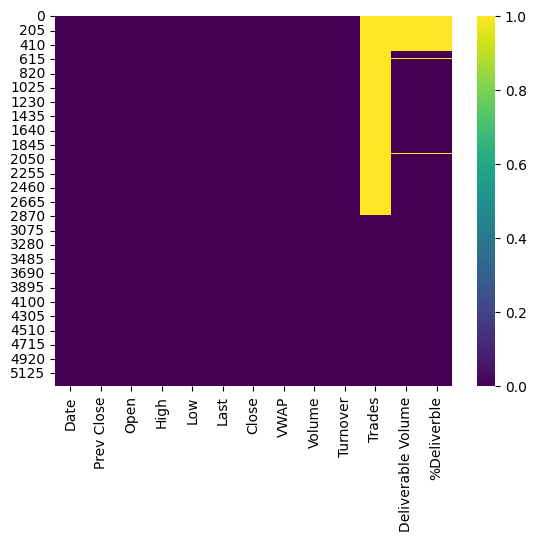

In [7]:
sns.heatmap(df.isnull(),cmap='viridis')

In [ ]:
#Deleting all the null rows
df = df.dropna()
#replacing the null values with 0


"""
We now have no null values in our data.
Before we move to scaling, let us also drop our%deliverable column as well as that is not asked in the question
"""

df = df.drop(columns=["%Deliverble"])
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 2456 entries, 2850 to 5305
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                2456 non-null   object 
 1   Prev Close          2456 non-null   float64
 2   Open                2456 non-null   float64
 3   High                2456 non-null   float64
 4   Low                 2456 non-null   float64
 5   Last                2456 non-null   float64
 6   Close               2456 non-null   float64
 7   VWAP                2456 non-null   float64
 8   Volume              2456 non-null   int64  
 9   Turnover            2456 non-null   float64
 10  Trades              2456 non-null   float64
 11  Deliverable Volume  2456 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 249.4+ KB


## Scaling our data

The data for your sequence prediction problem probably needs to be scaled when training a neural network, such as a Long Short-Term Memory recurrent neural network.

When a network is fit on unscaled data that has a range of values (e.g. quantities in the 10s to 100s) it is possible for large inputs to slow down the learning and convergence of your network and in some cases prevent the network from effectively learning your problem.

In [12]:
#We always scale our data before splitting it, now there are many ways of scaling our data
#we would use multiple ways to scale our data

#But firstly, let us separate our date from our df
#and keep a purely numeric dataset

numeric_df = df.drop(columns =["Date"])

Now we can't just apply any random scaling method to all our columns, we have to see what is the best for each type of column.

We took a look at how the data is spread for each of the 11 feature outputs, we noticed that the following are heavily skewed.
* Turnover
* Volume
* Trades
* Deliverable Volume

We will be applying log transformation on them

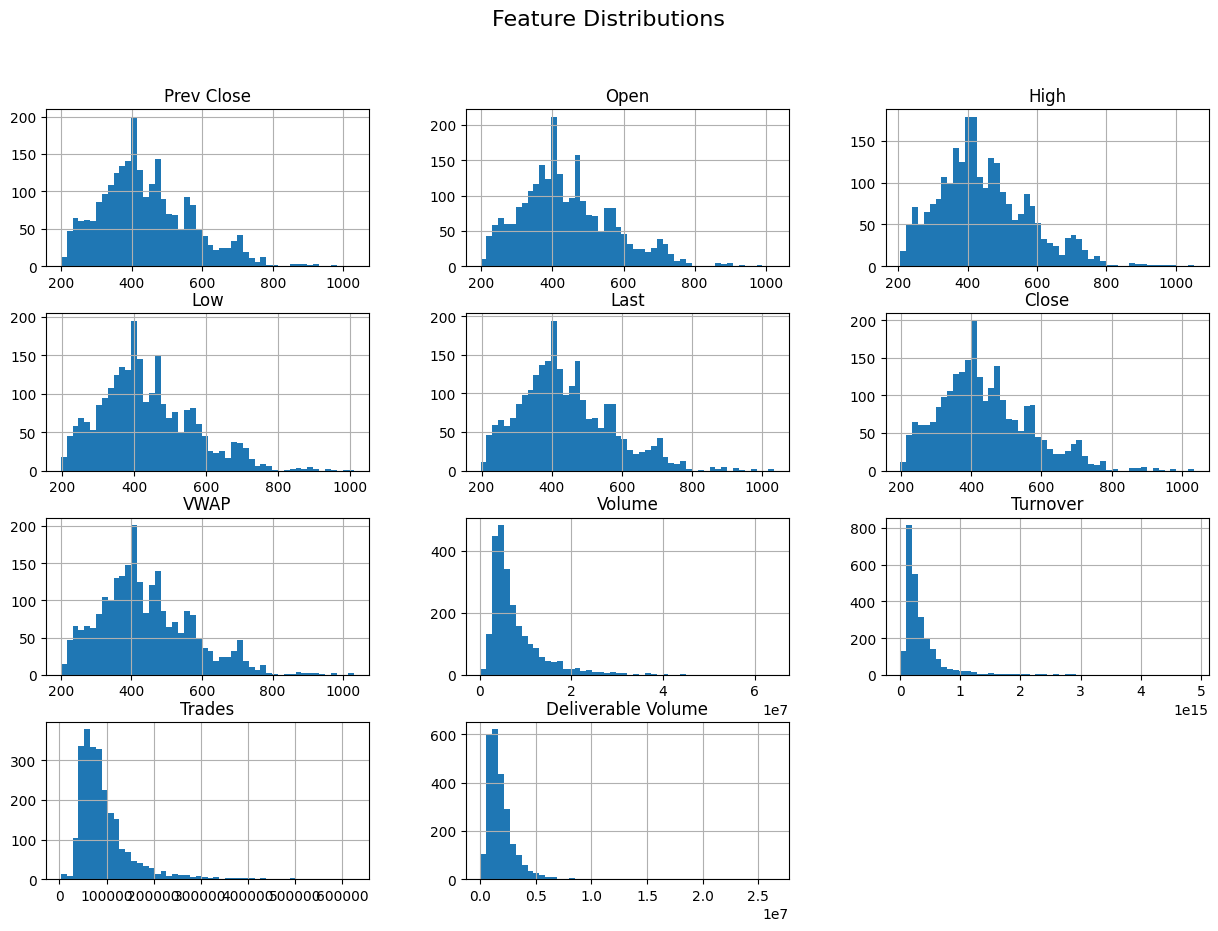

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot histograms to see the distribution shape
numeric_df.hist(figsize=(15, 10), bins=50)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

In [18]:
from sklearn.preprocessing import MinMaxScaler

#These are skewed cols, we would be applying log transformation on them
skewed_cols = ['Volume', 'Turnover', 'Trades', 'Deliverable Volume']
for col in skewed_cols:
    numeric_df[col] = np.log1p(numeric_df[col])

#Now perfectly safe to apply MinMaxScaler to the entire dataset
#NOte : this is after log transforming those 4 cols, we are minMaxScaling the entire data with them included

#Now remember, we dont scale our data before splitting it into test and train. 
#else scaling takes test data points into consideration
#So let us now do a train-test-validation split

data = numeric_df.values.astype(np.float32)


### Data Sequencing
This function uses a **sliding window approach** to prepare our time-series data for the LSTM. It chops the continuous dataset into discrete `(Input, Target)` pairs, where the input is `seq_length` days of historical data, and the target is the subsequent `pred_length` days we want to predict. Finally, it converts these arrays into PyTorch Tensors for model training.

In [19]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def create_sequences(data, seq_length, pred_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length - pred_length + 1):
        xs.append(data[i : i + seq_length])
        ys.append(data[i + seq_length : i + seq_length + pred_length])
    return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)

We will now process our data as follows
* Split into train,test,validation
* create sequences
* convert to tensors

In [56]:

#Train-Val-Test Split
train_ratio = 0.8
split_idx = int(len(data) * train_ratio)
train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)
train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

# MinMax Scaling (Remember : Fit ONLY on train_data!)
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Transform val and test using the train-fitted scaler
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)



Now we need to test our model for 2 cases
* Case 1
* * Input: last 5 days all 11 feature values, 
* * Output: predict next 5 days all 11 feature values. 

* Case 2
* * Input: last 10 days all 11 feature values,
* * Output: predict next 5 days all 11 feature values.


Let us first start with case 1

In [57]:
# 4. Generate Sequences & DataLoaders
seq_length = 5 #input
pred_length = 5 #output

X_train, y_train = create_sequences(train_data_scaled, seq_length, pred_length)
X_val, y_val = create_sequences(val_data_scaled, seq_length, pred_length)
X_test, y_test = create_sequences(test_data_scaled, seq_length, pred_length)

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print("Data pipeline complete! Ready for training.")
print(f"X_train shape: {X_train.shape}")

Data pipeline complete! Ready for training.
X_train shape: torch.Size([1562, 5, 11])


### Model Setup: Multi-Output LSTM
This cell defines the exact architecture of our neural network and sets up our training parameters.
* **The LSTM Layer:** Processes the historical daily data (11 features per day) over the given sequence length (e.g., 5 or 10 days).
* **The Linear Layer:** Takes the LSTM's final sequence summary and maps it to a flat array of 55 predictions.
* **Reshaping:** Converts those 55 predictions into the target grid of `(5 prediction days, 11 features)`.
* **Training Preparation:** Initializes the model, the Mean Squared Error (MSE) loss criterion, and the Adam optimizer (`lr=0.001`).

In [ ]:
import torch.nn as nn
import torch.optim as optim

class MultiOutputLSTM(nn.Module):
    def __init__(self, input_size=11, hidden_size=64, num_layers=2, pred_days=5):
        super(MultiOutputLSTM, self).__init__()
        self.pred_days = pred_days
        self.features = input_size
        
        # LSTM layer (batch_first=True for (batch, seq, feature) input shape)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Linear layer mapping hidden state to 55 output values
        self.fc = nn.Linear(hidden_size, pred_days * self.features)

    def forward(self, x):
        # Pass through LSTM
        lstm_out, _ = self.lstm(x)
        
        # Extract the hidden state from the final day of the 10-day sequence
        last_day_out = lstm_out[:, -1, :]
        
        # Generate predictions
        prediction = self.fc(last_day_out)
        
        # Reshape back to (batch_size, 5 days, 11 features)
        return prediction.view(-1, self.pred_days, self.features)

# Initialize the model
model = MultiOutputLSTM()

# Define Loss function and Optimizer
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

MultiOutputLSTM(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=55, bias=True)
)


### PyTorch Training & Validation Loop
This cell executes the standard PyTorch training cycle for 50 epochs, split into two main phases:
* **Training Phase (`model.train()`):** Iterates through the training batches. For each batch, it clears old gradients, performs a forward pass, calculates the loss, and updates the model weights using backpropagation (`loss.backward()` and `optimizer.step()`).
* **Validation Phase (`model.eval()`):** Temporarily disables gradient calculation using `torch.no_grad()` to save memory and compute. It evaluates the model on the validation set to monitor how well the network is generalizing to unseen data.
* **Logging:** Calculates and prints the average loss for both the training and validation sets every 10 epochs to help us monitor for convergence or overfitting.

In [59]:
# 1. Set number of epochs
epochs = 50 

print("Starting training...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Backward pass & optimize
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad(): # No need to calculate gradients for validation
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item()
            
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}')

Starting training...
Epoch [10/50] | Train Loss: 0.003184 | Val Loss: 0.005770
Epoch [20/50] | Train Loss: 0.003104 | Val Loss: 0.004748
Epoch [30/50] | Train Loss: 0.002953 | Val Loss: 0.005641
Epoch [40/50] | Train Loss: 0.002835 | Val Loss: 0.003915
Epoch [50/50] | Train Loss: 0.002757 | Val Loss: 0.003742


Test MSE: 391.1392
Test RMSE: 19.7772
Test MAE: 11.3532


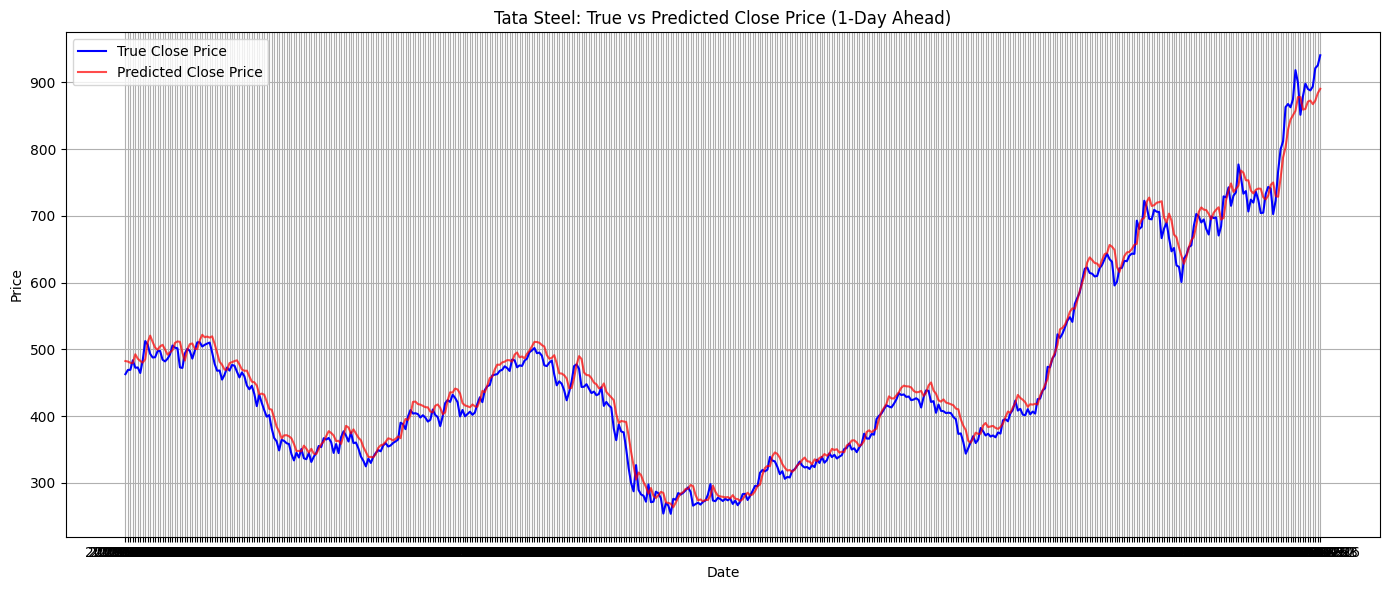

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set model to evaluation mode
model.eval()

# Get predictions on the test set
with torch.no_grad():
    test_predictions = model(X_test)

# Reshape arrays to 2D so the scaler can handle them
y_test_flat = y_test.numpy().reshape(-1, 11)
predictions_flat = test_predictions.numpy().reshape(-1, 11)

# Inverse transform to get real-world stock values
y_test_actual = scaler.inverse_transform(y_test_flat)
predictions_actual = scaler.inverse_transform(predictions_flat)

# Calculate Metrics
mse = mean_squared_error(y_test_actual, predictions_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions_actual)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")

#  Plotting
# Reshape back to 3D to easily grab the first day's prediction of the 'Close' price
y_test_3d = y_test_actual.reshape(-1, 5, 11)
preds_3d = predictions_actual.reshape(-1, 5, 11)

# Index 5 is 'Close' based on our feature list
close_idx = 5
true_close = y_test_3d[:, 0, close_idx]
pred_close = preds_3d[:, 0, close_idx]

# Grab the matching dates for the test set
test_start_idx = split_idx + seq_length
test_dates = df['Date'].iloc[test_start_idx : test_start_idx + len(true_close)]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, true_close, label='True Close Price', color='blue')
plt.plot(test_dates, pred_close, label='Predicted Close Price', color='red', alpha=0.7)
plt.title('Tata Steel: True vs Predicted Close Price (1-Day Ahead)')
plt.ylabel('Price')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

feature_names = numeric_df.columns
print("--- Error Metrics by Feature ---")
# feature_names is the list you created earlier: numeric_df.columns.tolist()
for i, feature in enumerate(feature_names):
    true_values = y_test_actual[:, i]
    pred_values = predictions_actual[:, i]
    
    feat_mse = mean_squared_error(true_values, pred_values)
    feat_rmse = np.sqrt(feat_mse)
    feat_mae = mean_absolute_error(true_values, pred_values)
    
    # Format the output so it aligns nicely
    print(f"{feature:>18} | RMSE: {feat_rmse:12.4f} | MAE: {feat_mae:12.4f}")

--- Error Metrics by Feature ---
        Prev Close | RMSE:      22.1886 | MAE:      15.3829
              Open | RMSE:      22.4412 | MAE:      16.0698
              High | RMSE:      24.4007 | MAE:      17.4165
               Low | RMSE:      24.9825 | MAE:      18.0198
              Last | RMSE:      26.9695 | MAE:      19.7280
             Close | RMSE:      26.8089 | MAE:      19.6076
              VWAP | RMSE:      25.3180 | MAE:      18.6309
            Volume | RMSE:       0.0112 | MAE:       0.0092
          Turnover | RMSE:       0.0043 | MAE:       0.0035
            Trades | RMSE:       0.0126 | MAE:       0.0098
Deliverable Volume | RMSE:       0.0098 | MAE:       0.0077


# Applying for Case 2

In [ ]:
# Generate Sequences & DataLoaders
seq_length = 10 #input
pred_length = 5 #output

X_train, y_train = create_sequences(train_data_scaled, seq_length, pred_length)
X_val, y_val = create_sequences(val_data_scaled, seq_length, pred_length)
X_test, y_test = create_sequences(test_data_scaled, seq_length, pred_length)

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print("Data pipeline complete! Ready for training.")
print(f"X_train shape: {X_train.shape}")

Data pipeline complete! Ready for training.
X_train shape: torch.Size([1557, 10, 11])


In [ ]:
import torch.nn as nn
import torch.optim as optim

class MultiOutputLSTM(nn.Module):
    def __init__(self, input_size=11, hidden_size=64, num_layers=2, pred_days=5):
        super(MultiOutputLSTM, self).__init__()
        self.pred_days = pred_days
        self.features = input_size
        
        # LSTM layer (batch_first=True for (batch, seq, feature) input shape)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Linear layer mapping hidden state to 55 output values
        self.fc = nn.Linear(hidden_size, pred_days * self.features)

    def forward(self, x):
        # Pass through LSTM
        lstm_out, _ = self.lstm(x)
        
        # Extract the hidden state from the final day of the 10-day sequence
        last_day_out = lstm_out[:, -1, :]
        
        # Generate predictions
        prediction = self.fc(last_day_out)
        
        # Reshape back to (batch_size, 5 days, 11 features)
        return prediction.view(-1, self.pred_days, self.features)

# Initialize the model
model = MultiOutputLSTM()

# Define Loss function and Optimizer
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

MultiOutputLSTM(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=55, bias=True)
)


In [44]:
# 1. Set number of epochs
epochs = 50 

print("Starting training...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Backward pass & optimize
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad(): # No need to calculate gradients for validation
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item()
            
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}')

Starting training...
Epoch [10/50] | Train Loss: 0.003275 | Val Loss: 0.005426
Epoch [20/50] | Train Loss: 0.003010 | Val Loss: 0.004899
Epoch [30/50] | Train Loss: 0.002909 | Val Loss: 0.004146
Epoch [40/50] | Train Loss: 0.002781 | Val Loss: 0.004165
Epoch [50/50] | Train Loss: 0.002780 | Val Loss: 0.004632


### Model Evaluation and Feature-Wise Predictions
This cell evaluates the trained model on the unseen test dataset. First, we generate predictions and use `inverse_transform` to convert the scaled numbers back into real-world stock metrics. After calculating the overall error metrics (MSE, RMSE, and MAE), we extract the 1-day ahead predictions for all 11 features and plot them on a 6x2 grid to visually inspect the model's accuracy across every variable.

Test MSE: 391.1392
Test RMSE: 19.7772
Test MAE: 11.3532


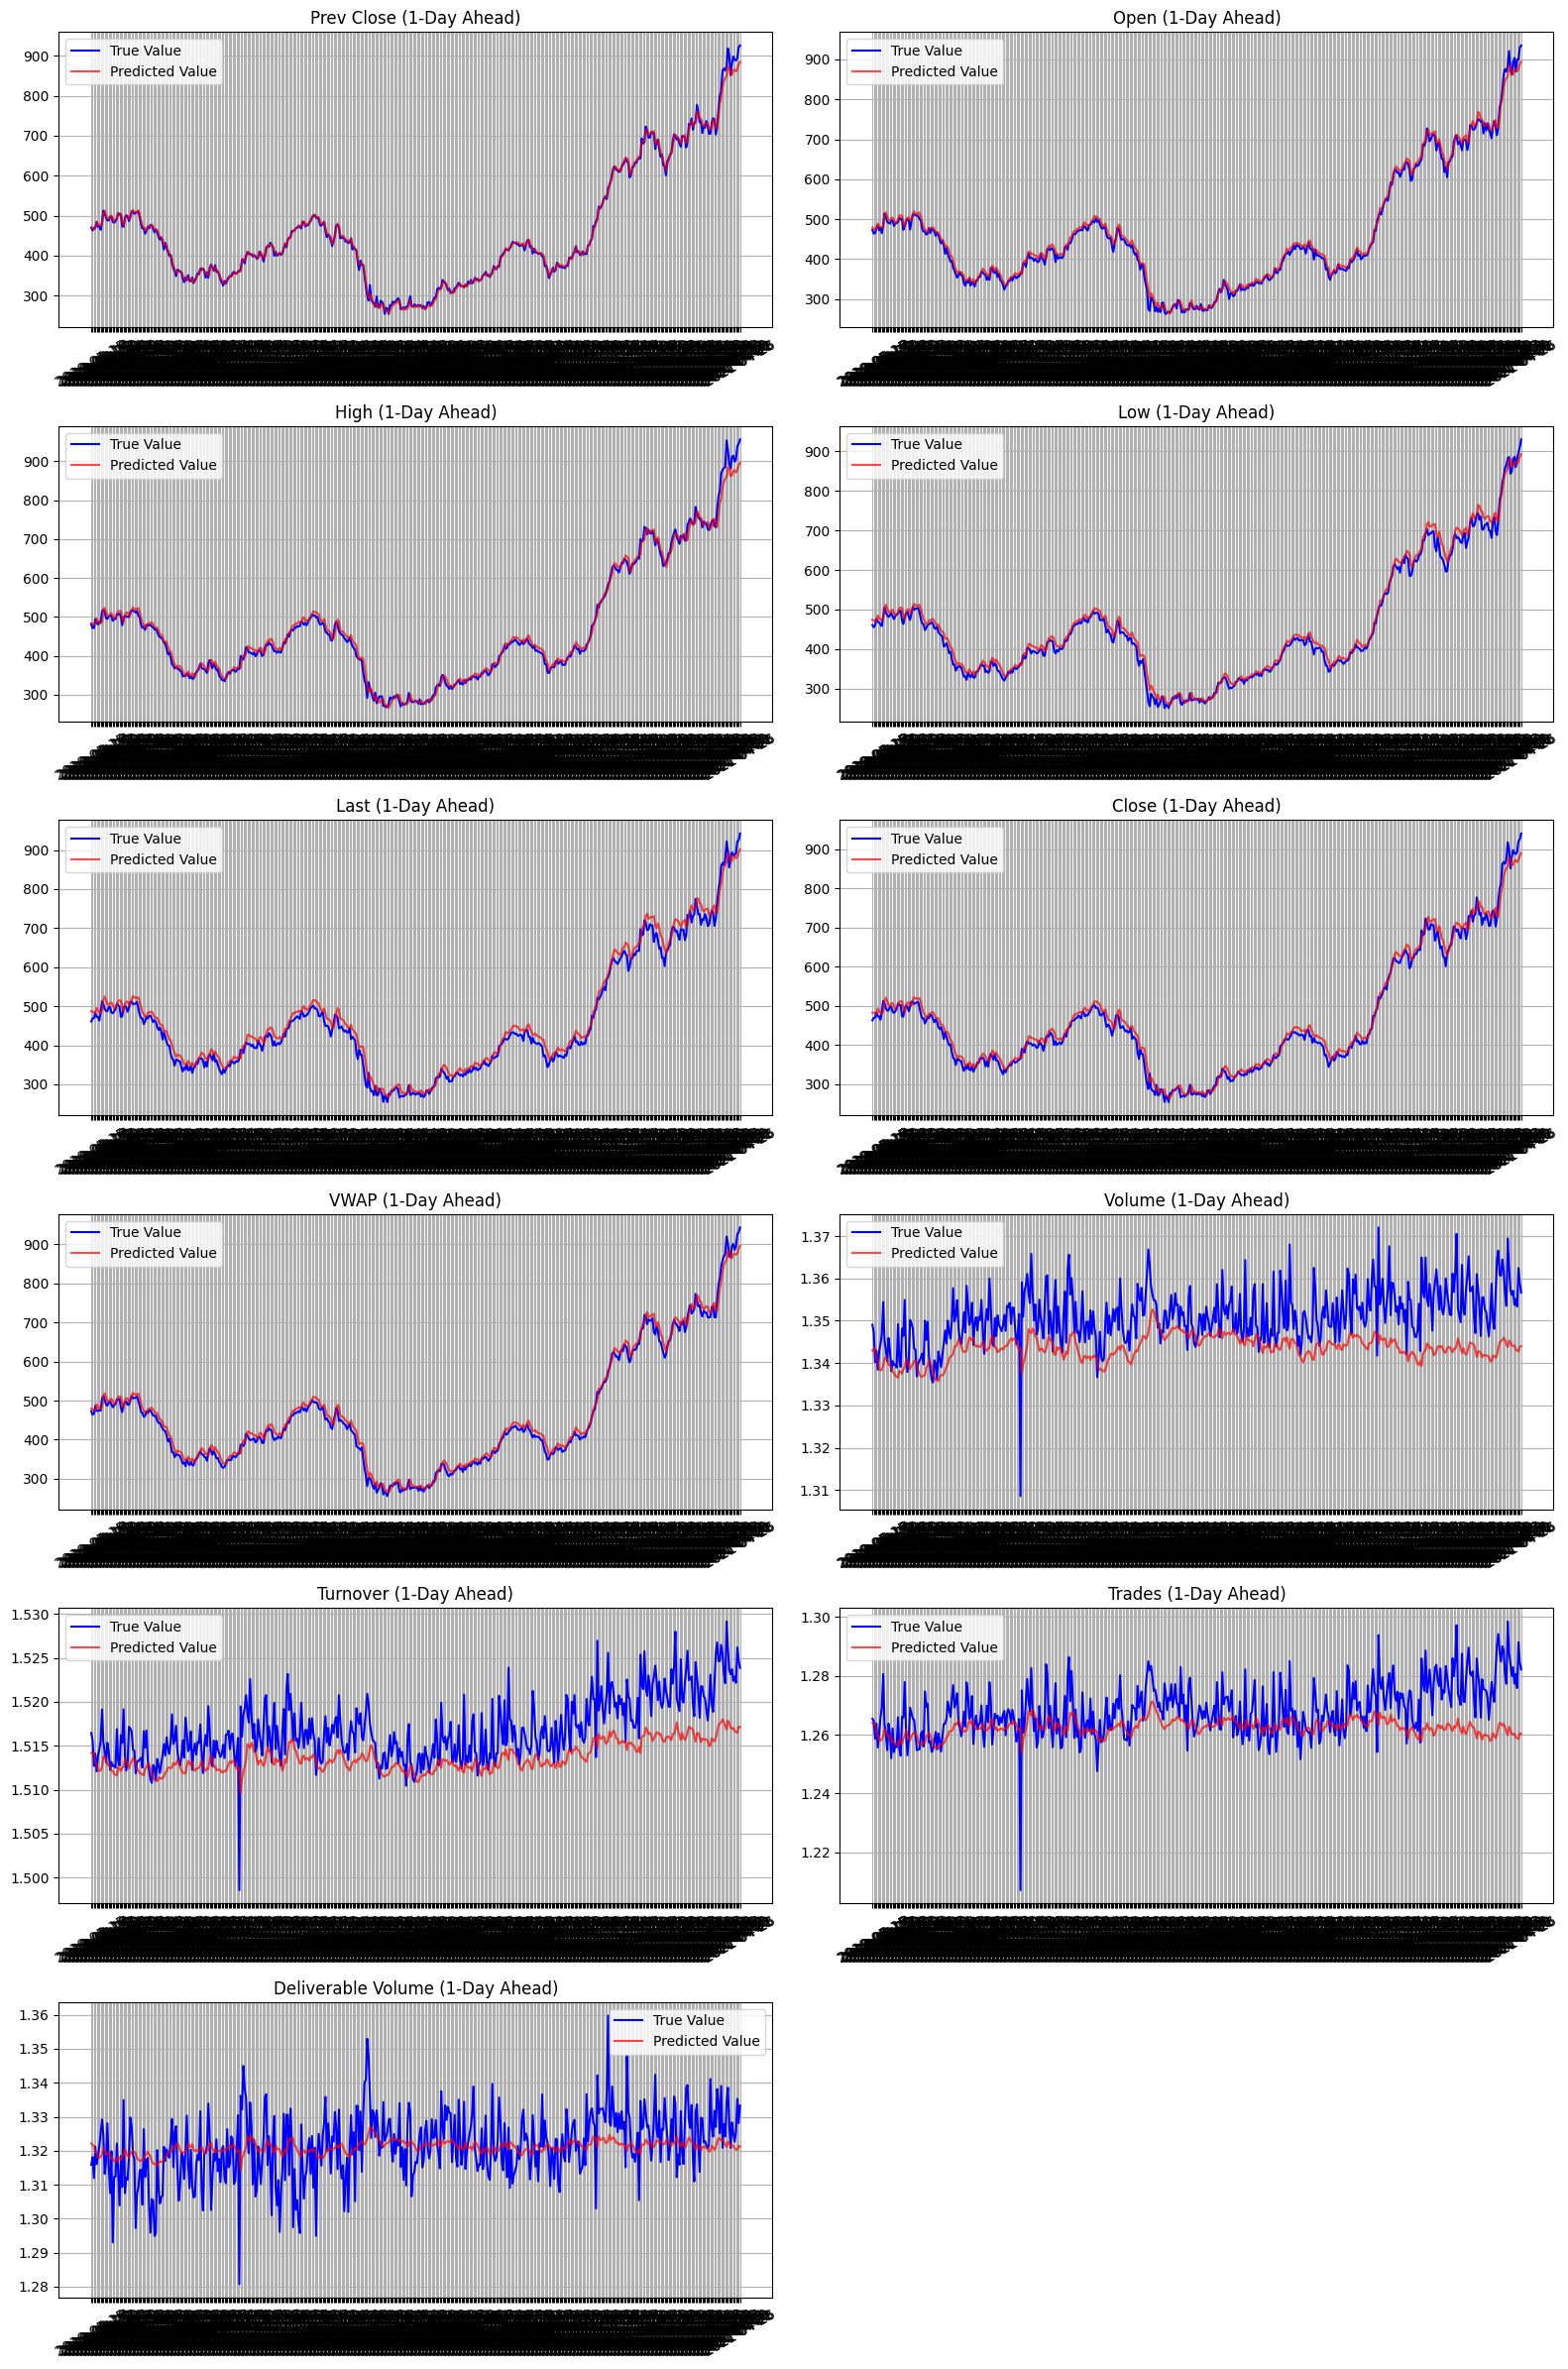

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set model to evaluation mode
model.eval()

#  Get predictions on the test set
with torch.no_grad():
    test_predictions = model(X_test)

# Reshape arrays to 2D so the scaler can handle them
y_test_flat = y_test.numpy().reshape(-1, 11)
predictions_flat = test_predictions.numpy().reshape(-1, 11)

# Inverse transform to get real-world stock values
y_test_actual = scaler.inverse_transform(y_test_flat)
predictions_actual = scaler.inverse_transform(predictions_flat)

# Calculate Metrics
mse = mean_squared_error(y_test_actual, predictions_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions_actual)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")

# Plotting All 11 Features in a 6x2 Grid
# Reshape back to 3D to easily grab the first day's prediction of all features
y_test_3d = y_test_actual.reshape(-1, 5, 11)
preds_3d = predictions_actual.reshape(-1, 5, 11)

# Grab the matching dates for the test set
test_start_idx = split_idx + seq_length
test_dates = df['Date'].iloc[test_start_idx : test_start_idx + len(y_test_3d)]

# Create a 6x2 grid of subplots
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(16, 24))
axes = axes.flatten() # Flatten to 1D array for easy looping

feature_names = numeric_df.columns 

for i in range(11):
    true_feat = y_test_3d[:, 0, i]
    pred_feat = preds_3d[:, 0, i]
    
    axes[i].plot(test_dates, true_feat, label='True Value', color='blue')
    axes[i].plot(test_dates, pred_feat, label='Predicted Value', color='red', alpha=0.7)
    axes[i].set_title(f'{feature_names[i]} (1-Day Ahead)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend()
    axes[i].grid(True)

# Delete the 12th empty subplot (index 11) so the grid looks clean
fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

In [65]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

feature_names = numeric_df.columns
print("--- Error Metrics by Feature ---")
# feature_names is the list you created earlier: numeric_df.columns.tolist()
for i, feature in enumerate(feature_names):
    true_values = y_test_actual[:, i]
    pred_values = predictions_actual[:, i]
    
    feat_mse = mean_squared_error(true_values, pred_values)
    feat_rmse = np.sqrt(feat_mse)
    feat_mae = mean_absolute_error(true_values, pred_values)
    
    # Format the output so it aligns nicely
    print(f"{feature:>18} | RMSE: {feat_rmse:12.4f} | MAE: {feat_mae:12.4f}")

--- Error Metrics by Feature ---
        Prev Close | RMSE:      22.1886 | MAE:      15.3829
              Open | RMSE:      22.4412 | MAE:      16.0698
              High | RMSE:      24.4007 | MAE:      17.4165
               Low | RMSE:      24.9825 | MAE:      18.0198
              Last | RMSE:      26.9695 | MAE:      19.7280
             Close | RMSE:      26.8089 | MAE:      19.6076
              VWAP | RMSE:      25.3180 | MAE:      18.6309
            Volume | RMSE:       0.0112 | MAE:       0.0092
          Turnover | RMSE:       0.0043 | MAE:       0.0035
            Trades | RMSE:       0.0126 | MAE:       0.0098
Deliverable Volume | RMSE:       0.0098 | MAE:       0.0077


# Let us now compare the 2 cases and their outputs

In [66]:
print("CASE 1\n\n")
print(f"Test MSE CASE : {mse:.4f}")
print(f"Test RMSE CASE : {rmse:.4f}")
print(f"Test MAE CASE : {mae:.4f}")

print("\n\nCASE 2\n\n")


print(f"Test MSE CASE 2: {mse_2:.4f}")
print(f"Test RMSE CASE 2: {rmse_2:.4f}")
print(f"Test MAE CASE 2: {mae_2:.4f}")





CASE 1


Test MSE CASE : 391.1392
Test RMSE CASE : 19.7772
Test MAE CASE : 11.3532


CASE 2


Test MSE CASE 2: 379.2318
Test RMSE CASE 2: 19.4739
Test MAE CASE 2: 10.8460


## Submission Details
* **Roll Number:** 202502831
* **Dataset:** TATASTEEL.csv
* **GitHub Repository:** [[Link](https://github.com/msh165/jmi-msc-ai-ml-RNN-tatasteel-multi-feature-output)]